# Behavior-Centered Vectorization
## Get largest R-sq source monkey for each behavior and vectorize (6-dim)

In [2]:
from analyses.linear_regression.post_ols_analysis import plot_cross_meta_from_filtered_df
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


/home/connorlab/miniconda3/envs/neural_analysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-08 14:54:02.638384: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [26]:
significant_results = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/Zombies_dir_ols_on_single_neurons.pkl')
significant_results = significant_results[significant_results['p_value'] < 0.05]
significant_results = significant_results[significant_results['R-squared'] > 0.5]
# significant_results = significant_results[significant_results['NeuronID'].str.contains("Unit")]
# significant_results.shape
significant_results['NeuronID'].nunique()

285

In [27]:
significant_results

,NeuronID,Behavior,Source_Monkey,Model,R-squared,coef,p_value
11697,AMG_2023-09-29_3_Channel.C_010,AgonismTo,143H,ols,0.500187,0.391699,0.049763
10601,ER_2023-11-25_2_Channel.C_000,SubmissionFrom,151J,ols,0.500188,-1.850087,0.049763
5869,AMG_2023-09-26_3_Channel.C_013,SubmissionTo,69X,ols,0.500225,-0.686904,0.049751
5871,AMG_2023-09-26_3_Channel.C_013,SubmissionTo,94B,ols,0.500259,-0.682857,0.049739
11955,AMG_2023-10-04_1_Channel.C_004_Unit 1,AgonismTo,94B,ols,0.500310,0.361264,0.049723
...,...,...,...,...,...,...,...
2836,Unknown_2023-12-18_3_Channel.C_003,AffiliationTo,69X,ols,0.912103,0.494895,0.000220
14956,AMG_2023-10-04_2_Channel.C_020_Unit 2,AgonismFrom,87J,ols,0.924980,0.815945,0.000136
5707,Unknown_2023-12-18_3_Channel.C_003,AffiliationFrom,69X,ols,0.925018,0.498386,0.000136
8458,ER_2023-12-14_4_Channel.C_004,SubmissionTo,87J,ols,0.925692,0.329421,0.000132


In [15]:
filtered_df = (
        significant_results
        .sort_values('R-squared', ascending=False)
        .drop_duplicates(['NeuronID', 'Behavior'])
    )
filtered_df = filtered_df.reset_index(drop=True)
# Step 1: pivot (NeuronID × Behavior) wide format 만들기
pivot_df = filtered_df.pivot(index='NeuronID', columns='Behavior', values='R-squared').fillna(0)
# pivot_df[pivot_df < 0.05] = 0
pivot_df = pivot_df[(pivot_df > 0).sum(axis=1) >= 2]


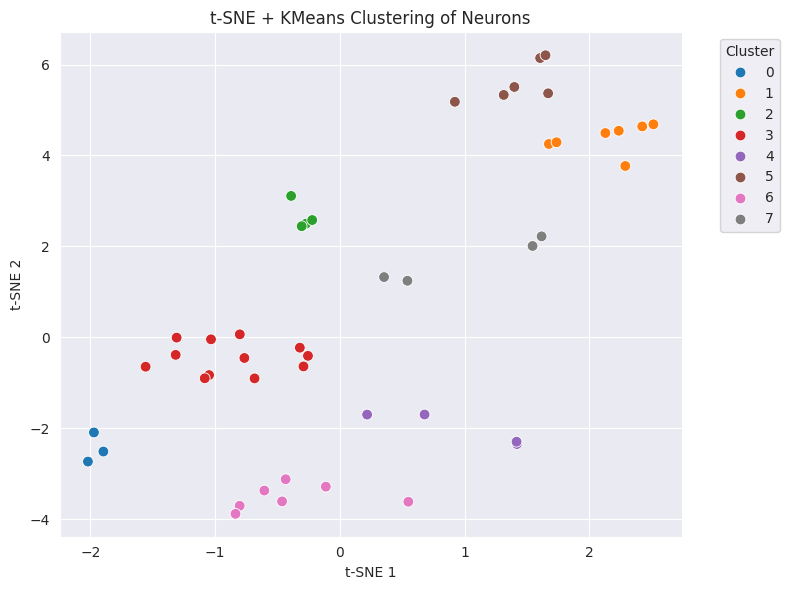

In [16]:


# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(pivot_df)
# t-SNE
tsne = TSNE(n_components=2, perplexity=20, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(pivot_df)

# KMeans clustering
kmeans = KMeans(n_clusters=8, random_state=42, n_init=30)
cluster_labels = kmeans.fit_predict(tsne_coords)

# add cluster colors to t-sne plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE + KMeans Clustering of Neurons")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

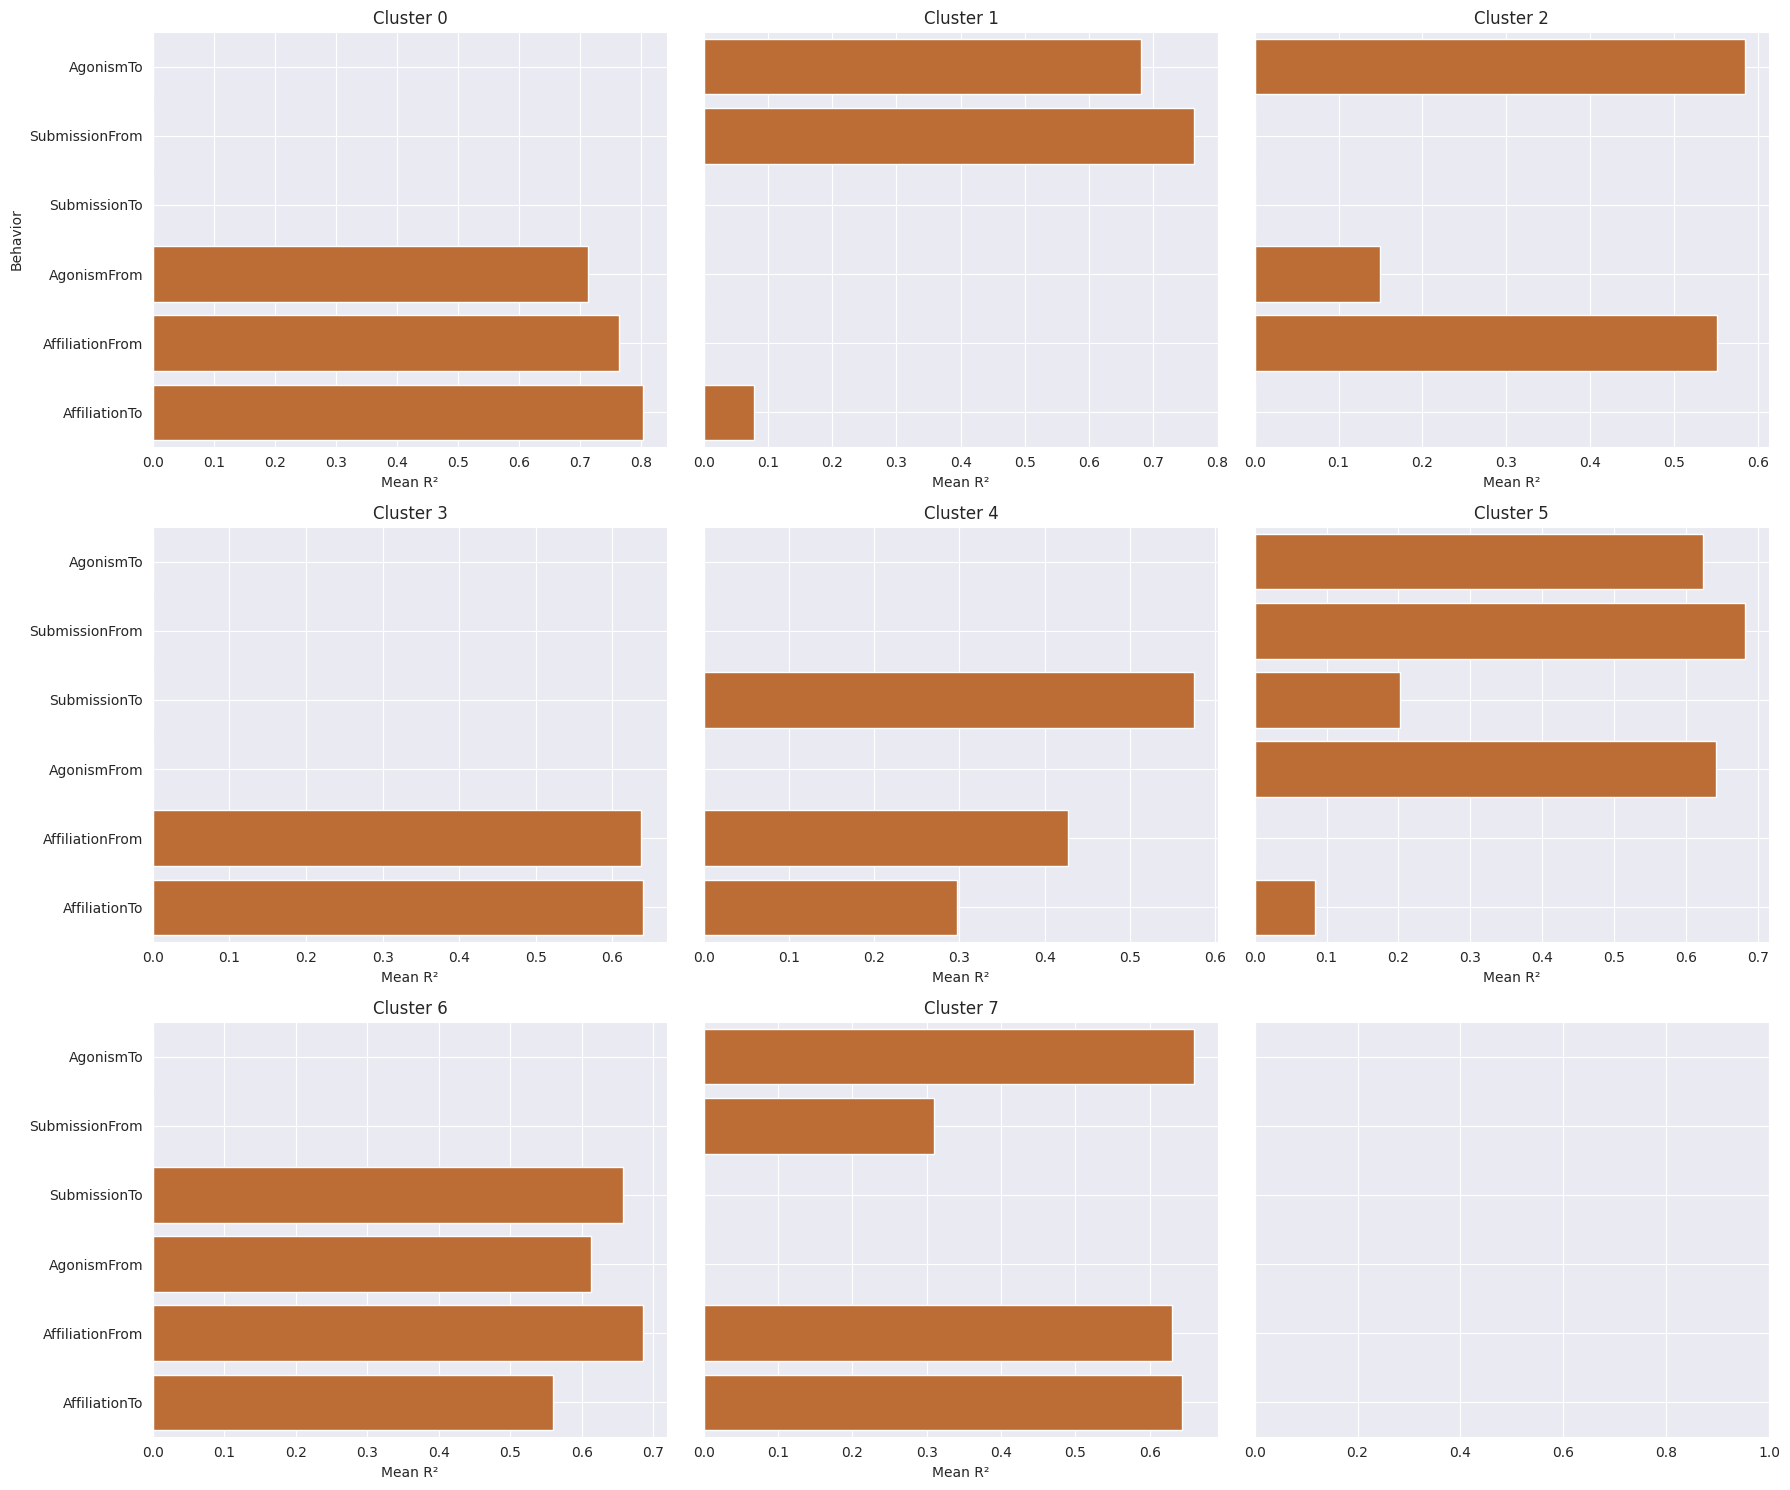

In [23]:
cluster_series = pd.Series(cluster_labels)
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_labels
n_clusters = cluster_series.nunique()
# Figure setup
ncols = 3
nrows = (n_clusters + ncols - 1) // ncols  # 자동 계산

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharey=True)

axes = axes.flatten()
for i, cluster_id in enumerate(sorted(cluster_series.unique())):
    ax = axes[i] if n_clusters > 1 else axes

    cluster_df = pivot_df_clustered[pivot_df_clustered[('Cluster'
                                                        '')] == cluster_id].drop(columns='Cluster')
    mean_r2 = cluster_df.mean().sort_values(ascending=True)  # <- barh로 그릴거라서 ascending=True

    sns.barplot(x=mean_r2.values, y=mean_r2.index, ax=ax, color='chocolate')
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Mean R²")
    if i == 0:
        ax.set_ylabel("Behavior")
    else:
        ax.set_ylabel("")
    ax.grid(True)

plt.tight_layout()
plt.show()


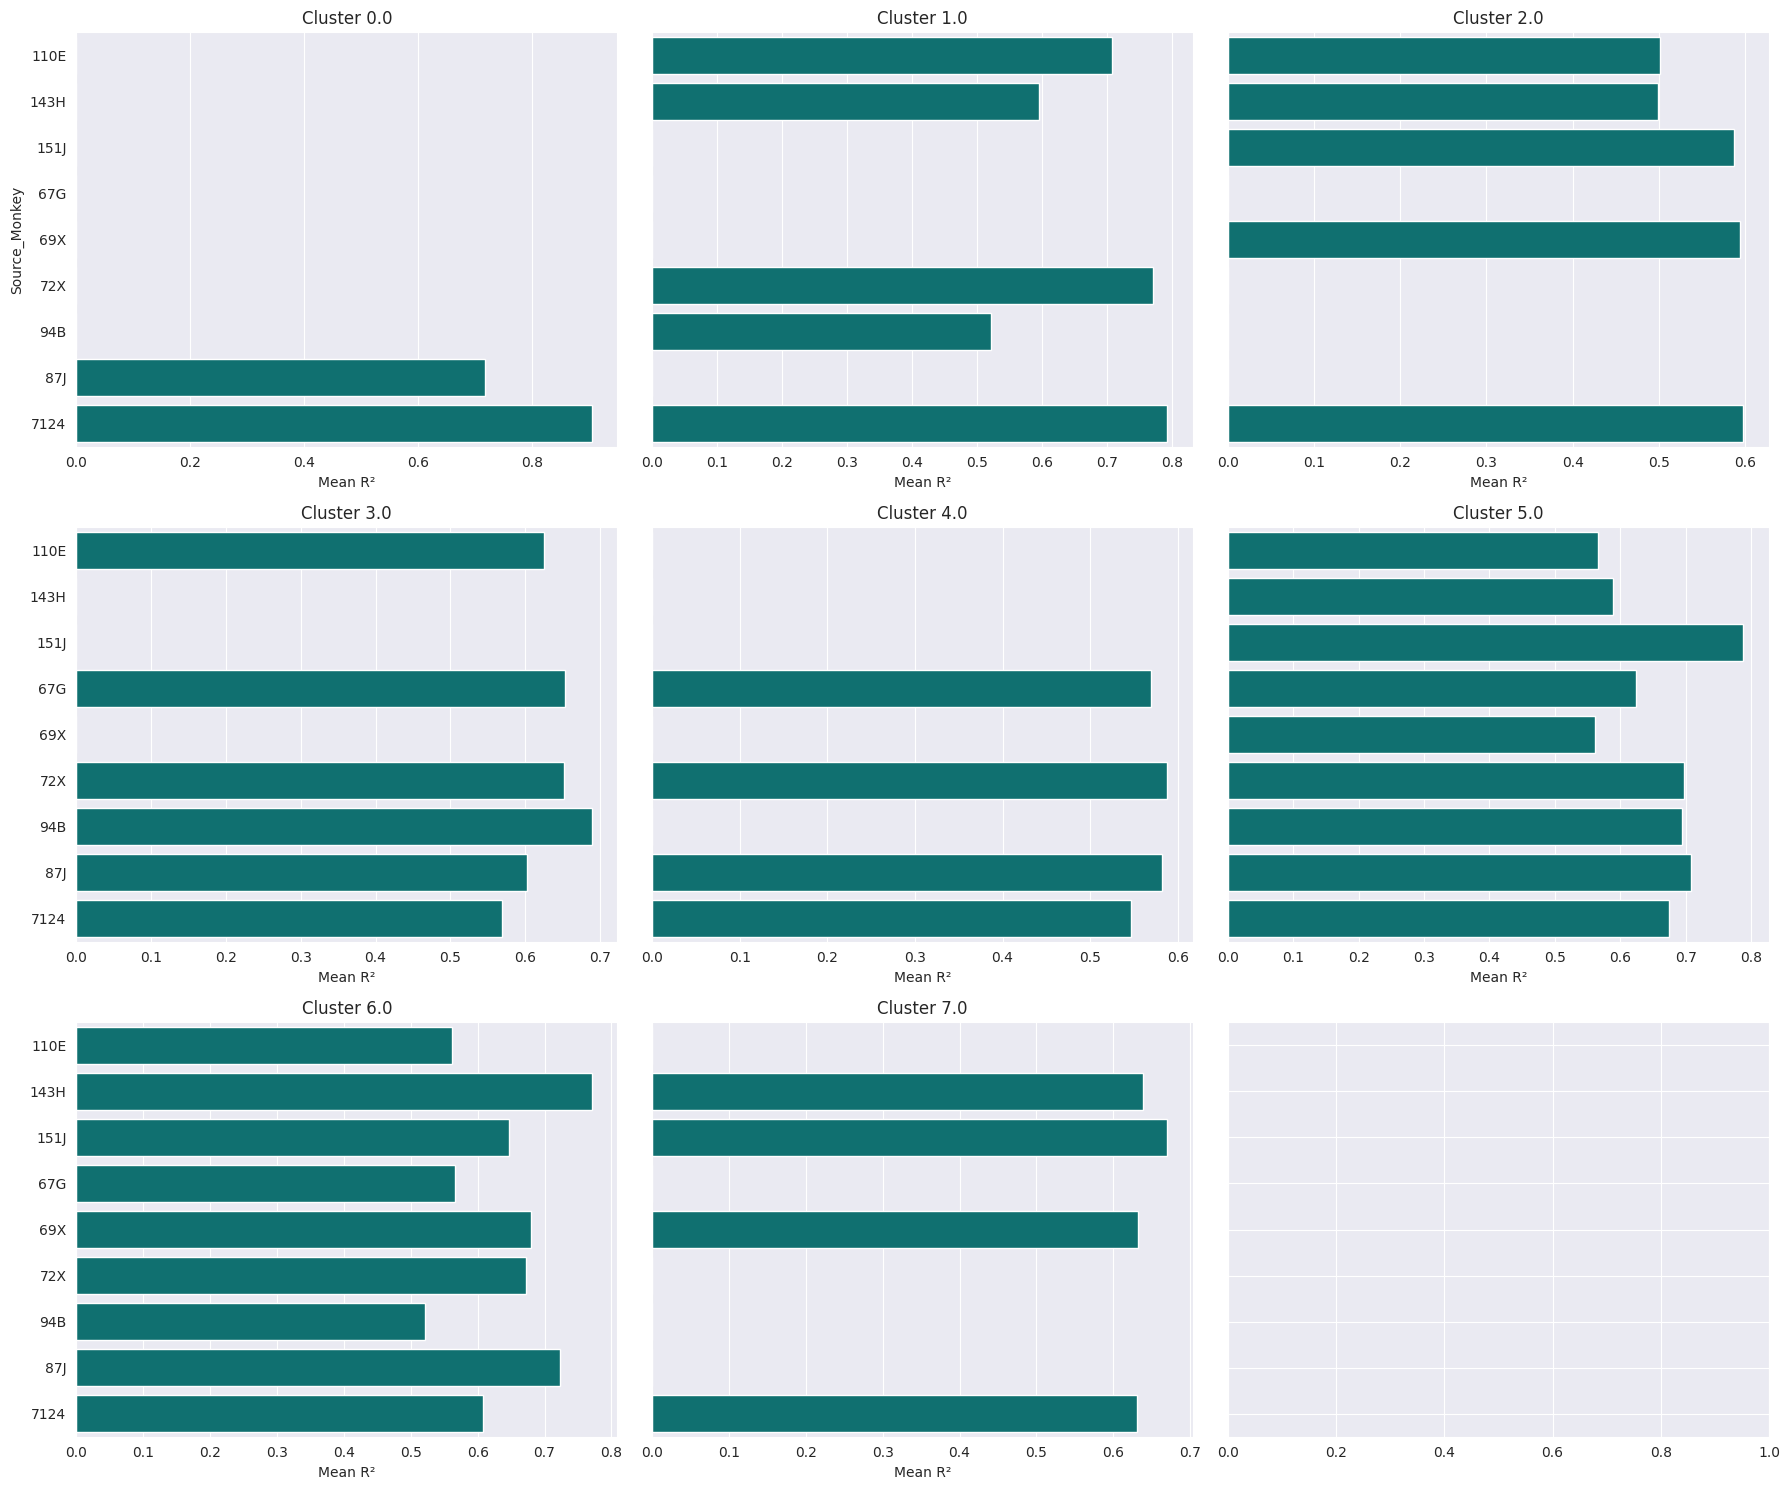

In [24]:
from analyses.linear_regression.post_ols_analysis import plot_cross_meta_from_filtered_df
plot_cross_meta_from_filtered_df(filtered_df, pivot_df, cluster_labels, category_col="Source_Monkey")

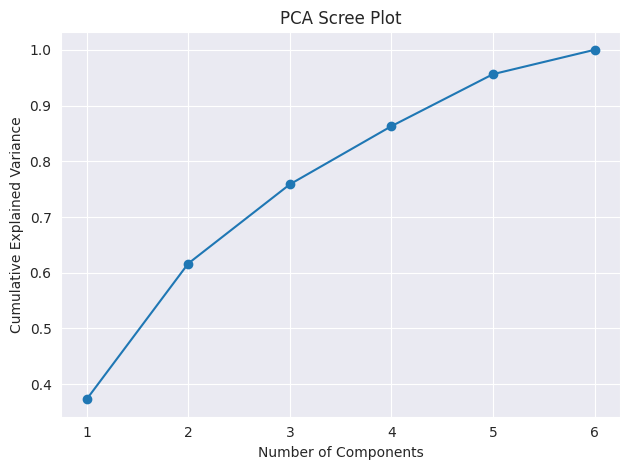

In [10]:
# Step 1: PCA
pca = PCA()
pca_result = pca.fit_transform(pivot_df)

# Step 2: Scree plot to decide # of components
explained_var = pca.explained_variance_ratio_
plt.plot(range(1, len(explained_var)+1), explained_var.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

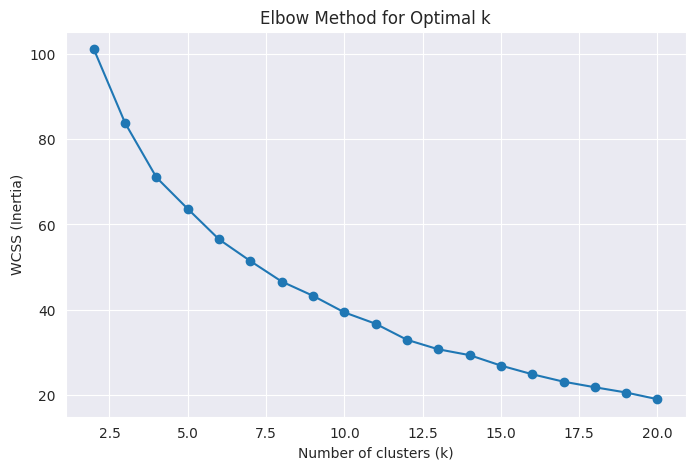

In [11]:
# Elbow plot to see n_cluster is the best
inertia = []
k_range = range(2, 21)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pivot_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.show()

In [ ]:
# to determine how many clusters (n_clustsers)
from sklearn.metrics import silhouette_score

scores = []
k_range = range(2, 21)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pivot_df)
    score = silhouette_score(pivot_df, labels)
    scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range, scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal k")
plt.show()


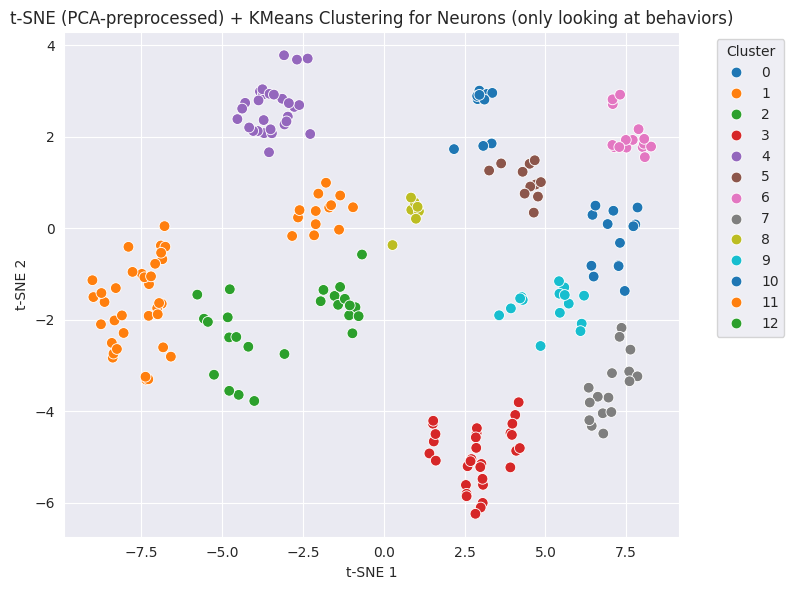

In [12]:
# Step 3: Keep N components based on scree plot
n_components = 3  # Example, pick based on where curve levels off
pca = PCA(n_components=n_components)
pca_reduced = pca.fit_transform(pivot_df)

# Step 4: t-SNE on PCA-reduced data
tsne = TSNE(n_components=2, perplexity=50, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(pca_reduced)

# Step 5: KMeans clustering
kmeans = KMeans(n_clusters=13, random_state=42, n_init=30)
cluster_labels = kmeans.fit_predict(tsne_coords)

# Step 6: Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE (PCA-preprocessed) + KMeans Clustering for Neurons (only looking at behaviors)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

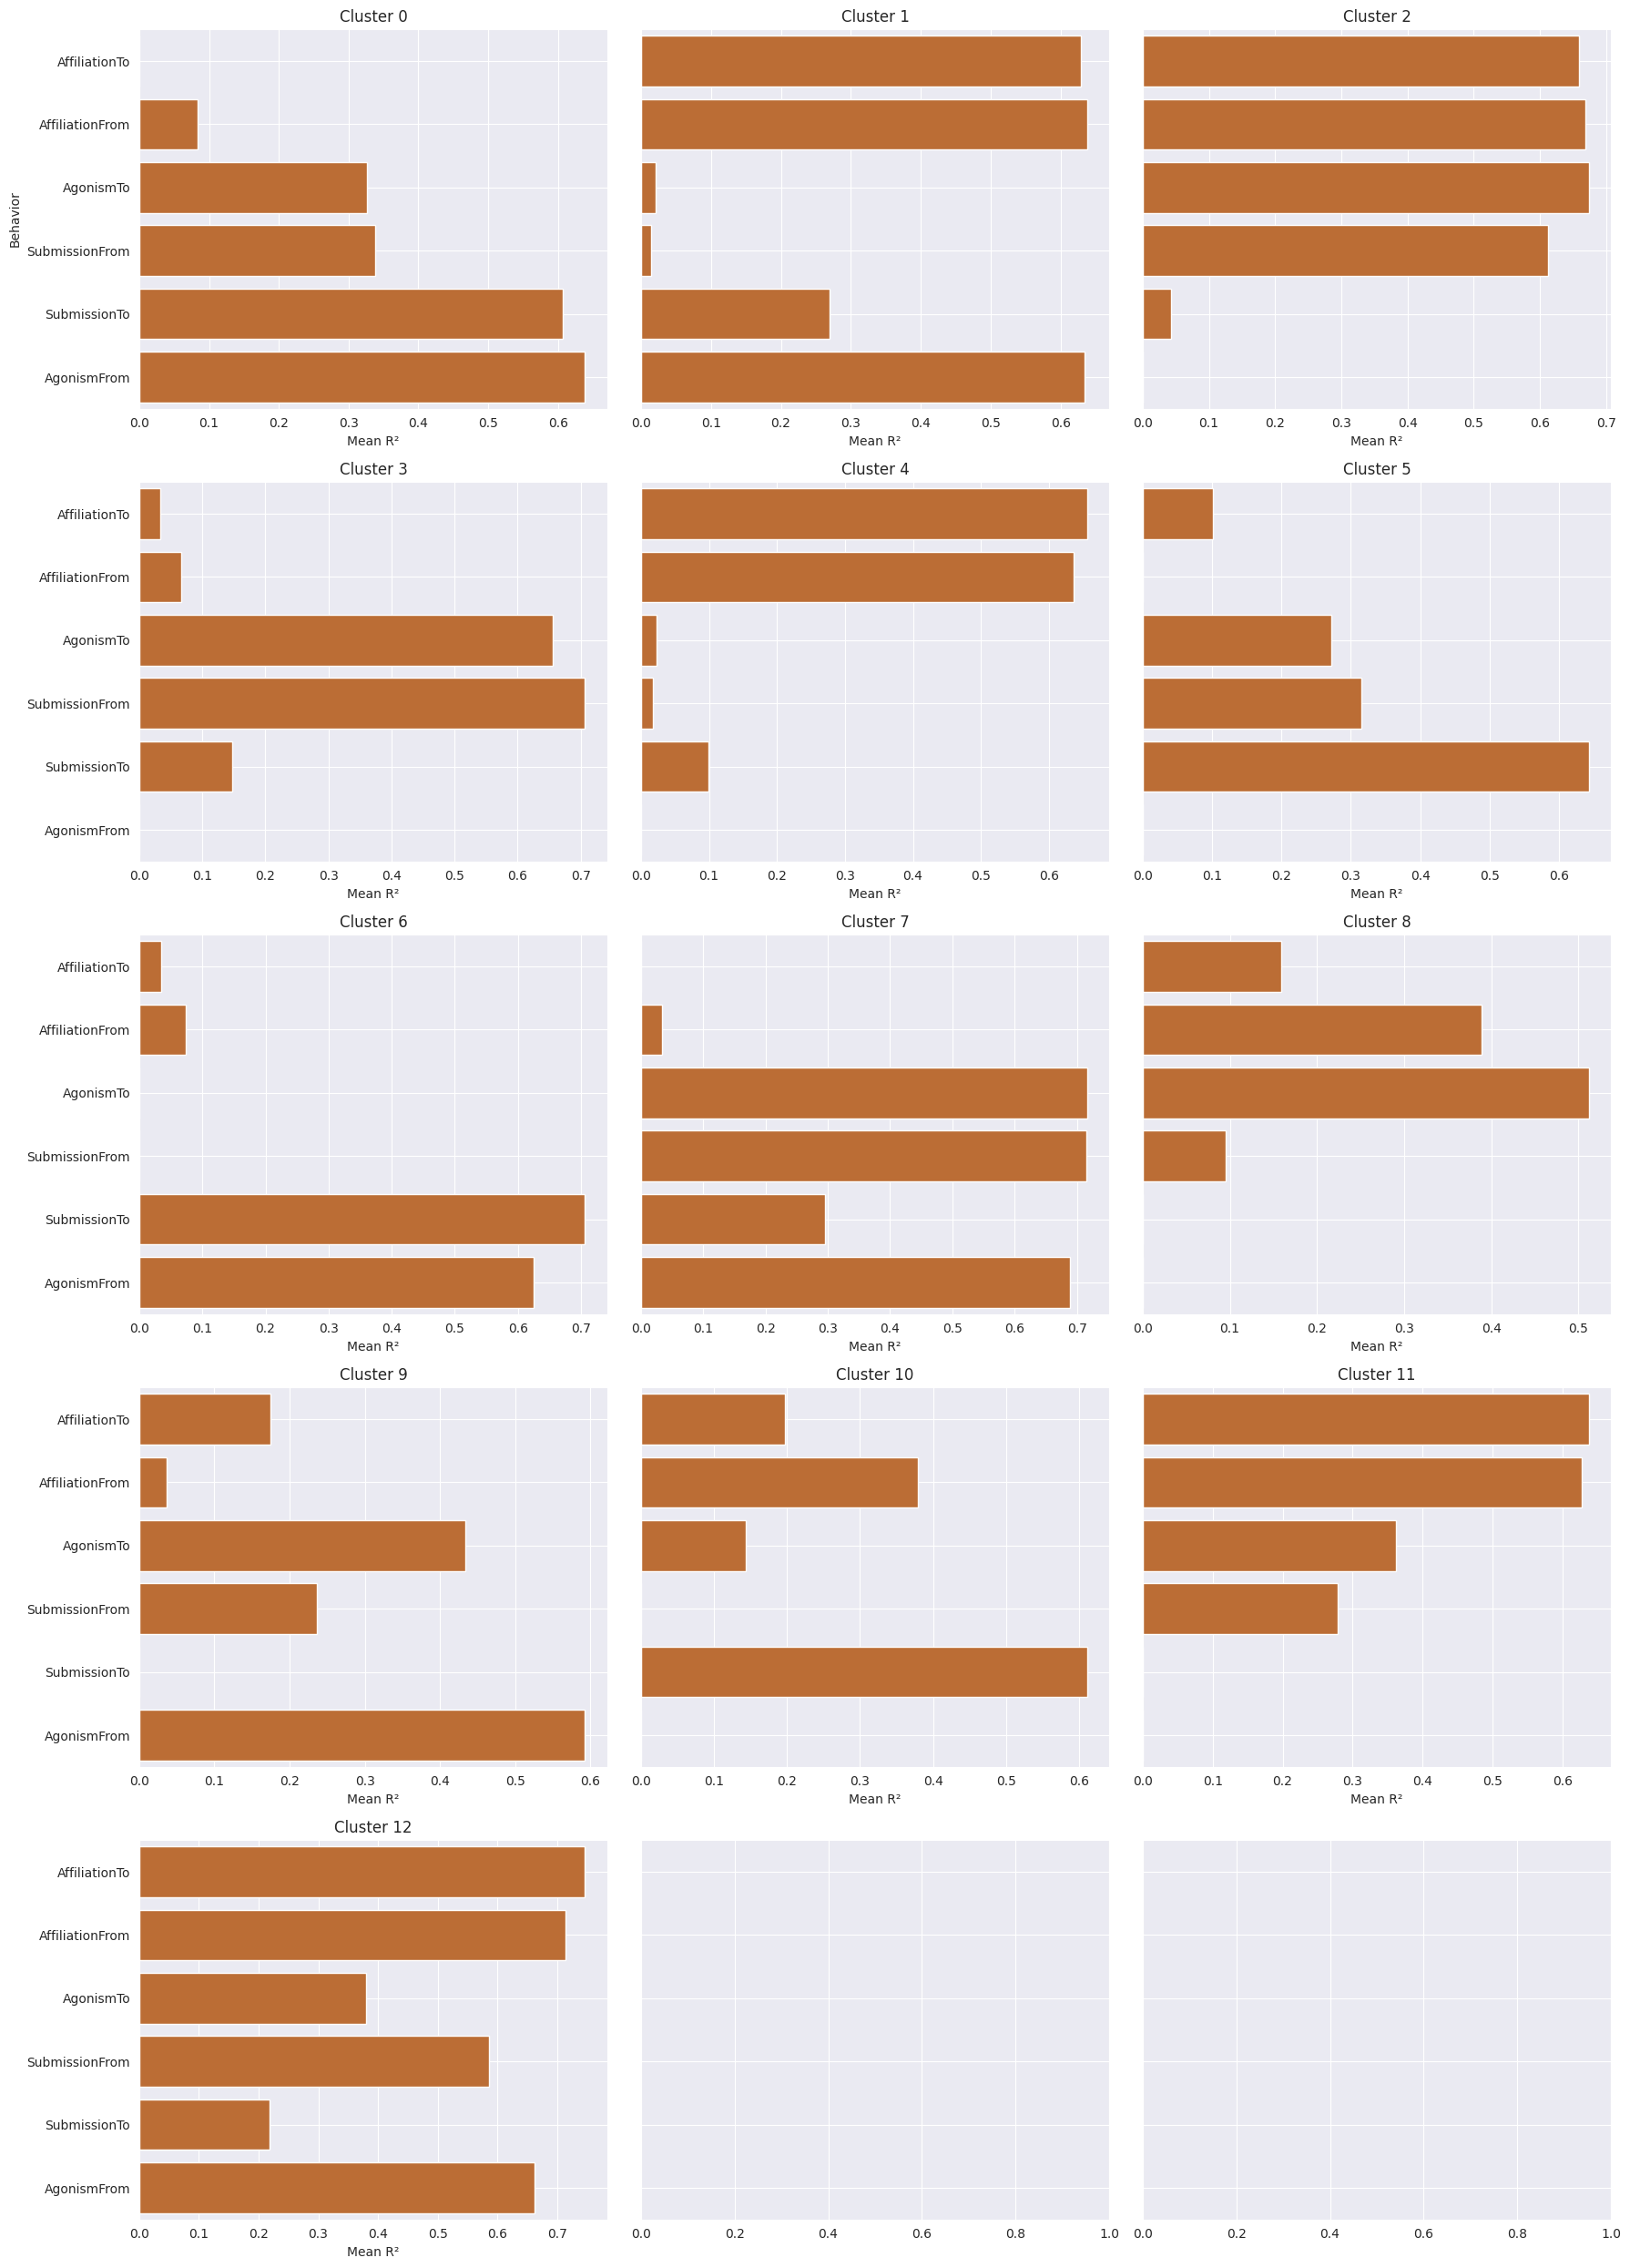

In [13]:
cluster_series = pd.Series(cluster_labels)
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_labels
n_clusters = cluster_series.nunique()
# Figure setup
ncols = 3
nrows = (n_clusters + ncols - 1) // ncols  # 자동 계산

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharey=True)

axes = axes.flatten()
for i, cluster_id in enumerate(sorted(cluster_series.unique())):
    ax = axes[i] if n_clusters > 1 else axes

    cluster_df = pivot_df_clustered[pivot_df_clustered['Cluster'] == cluster_id].drop(columns='Cluster')
    mean_r2 = cluster_df.mean().sort_values(ascending=True)

    sns.barplot(x=mean_r2.values, y=mean_r2.index, ax=ax, color='chocolate')
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Mean R²")
    if i == 0:
        ax.set_ylabel("Behavior")
    else:
        ax.set_ylabel("")
    ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
pivot_df_clustered[pivot_df_clustered['Cluster'] == 5]

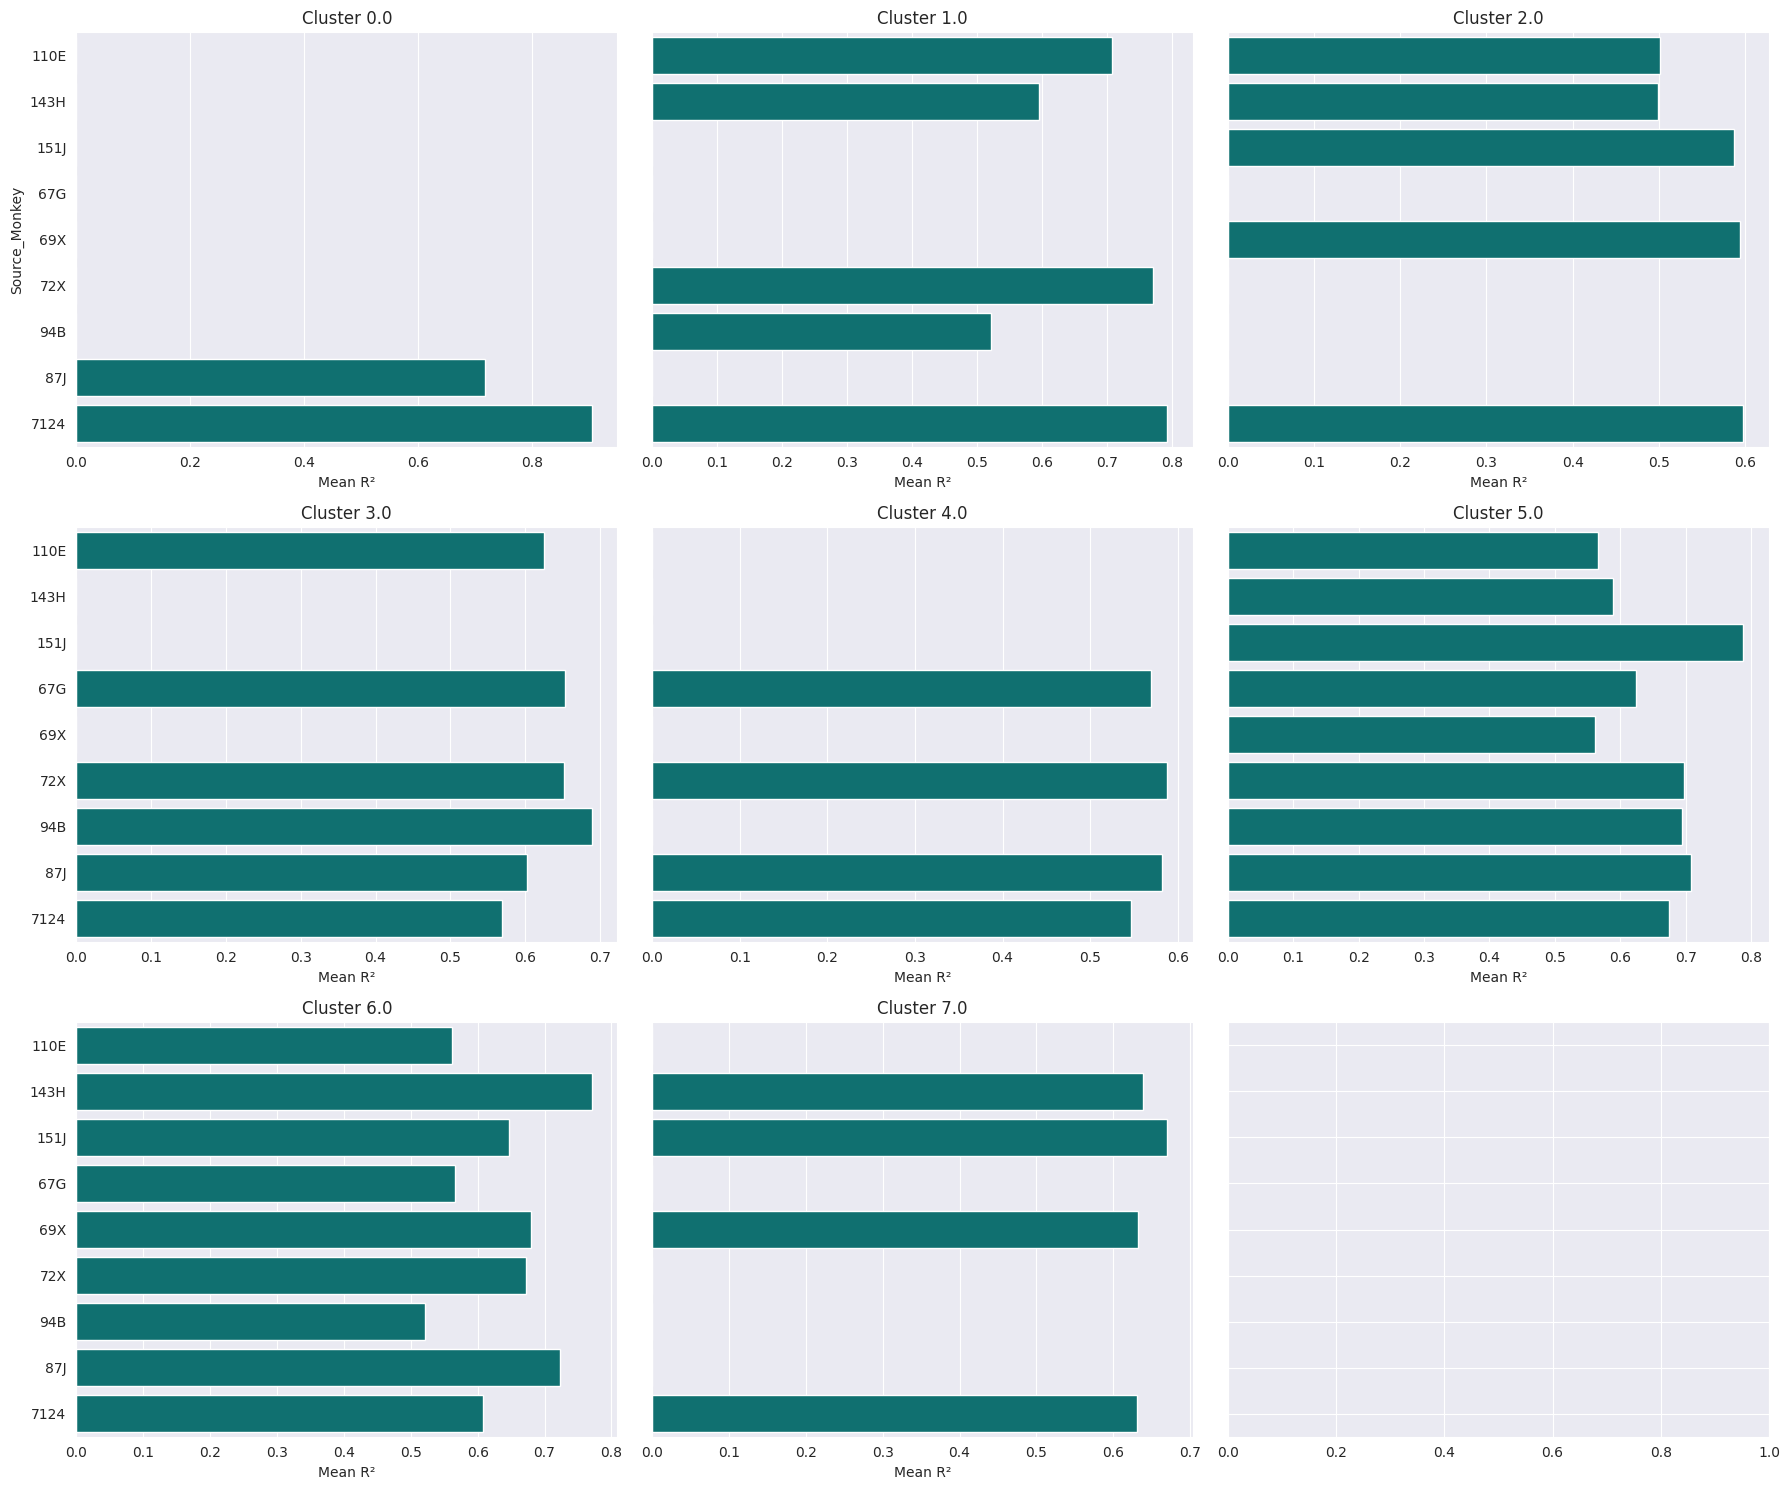

In [22]:
from analyses.linear_regression.post_ols_analysis import plot_cross_meta_from_filtered_df
plot_cross_meta_from_filtered_df(filtered_df, pivot_df, cluster_labels, category_col="Source_Monkey")